In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.getcwd())
from utils import evaluate_model, temporal_split
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/tea_demand_dataset.csv', parse_dates=['week_start_date'])
df = df.sort_values(['grade', 'week_start_date']).reset_index(drop=True)

grades_raw = df['grade'].unique()
results    = []
os.makedirs('results', exist_ok=True)
os.makedirs('plots',   exist_ok=True)

print("Grades:", grades_raw)

Grades: ['BOP' 'BOPF' 'Dust' 'OP' 'Pekoe']


In [2]:
print("Running Naive Seasonal Baseline...")

for grade in grades_raw:
    train, test = temporal_split(df[df['grade'] == grade])
    
    # Naive seasonal: use value from exactly 52 weeks ago
    naive_pred = train['demand_kg'].values[-len(test):]
    if len(naive_pred) < len(test):
        naive_pred = np.tile(naive_pred, int(np.ceil(len(test)/len(naive_pred))))[:len(test)]
    
    metrics = evaluate_model(f'Naive Seasonal ({grade})',
                              test['demand_kg'].values, naive_pred)
    metrics['grade'] = grade
    results.append(metrics)

Running Naive Seasonal Baseline...

  Model: Naive Seasonal (BOP)
  MAE   : 530.77 kg
  RMSE  : 652.44 kg
  MAPE  : 12.74%
  sMAPE : 13.43%

  Model: Naive Seasonal (BOPF)
  MAE   : 708.21 kg
  RMSE  : 870.24 kg
  MAPE  : 14.91%
  sMAPE : 15.37%

  Model: Naive Seasonal (Dust)
  MAE   : 1045.88 kg
  RMSE  : 1378.82 kg
  MAPE  : 15.15%
  sMAPE : 16.26%

  Model: Naive Seasonal (OP)
  MAE   : 225.90 kg
  RMSE  : 269.72 kg
  MAPE  : 9.59%
  sMAPE : 9.58%

  Model: Naive Seasonal (Pekoe)
  MAE   : 176.63 kg
  RMSE  : 223.26 kg
  MAPE  : 10.79%
  sMAPE : 11.34%


In [3]:
print("\nRunning Holt-Winters ETS...")

for grade in grades_raw:
    train, test = temporal_split(df[df['grade'] == grade])
    
    model = ExponentialSmoothing(
        train['demand_kg'],
        trend='add',
        seasonal='add',
        seasonal_periods=52,
        damped_trend=True
    ).fit(optimized=True)
    
    pred    = model.forecast(len(test))
    metrics = evaluate_model(f'Holt-Winters ({grade})',
                              test['demand_kg'].values, pred.values)
    metrics['grade'] = grade
    results.append(metrics)

print("\nHolt-Winters done.")


Running Holt-Winters ETS...

  Model: Holt-Winters (BOP)
  MAE   : 402.34 kg
  RMSE  : 522.67 kg
  MAPE  : 9.42%
  sMAPE : 9.88%

  Model: Holt-Winters (BOPF)
  MAE   : 538.62 kg
  RMSE  : 690.40 kg
  MAPE  : 11.31%
  sMAPE : 11.71%

  Model: Holt-Winters (Dust)
  MAE   : 897.84 kg
  RMSE  : 1146.85 kg
  MAPE  : 13.29%
  sMAPE : 13.91%

  Model: Holt-Winters (OP)
  MAE   : 195.77 kg
  RMSE  : 248.91 kg
  MAPE  : 8.28%
  sMAPE : 8.28%

  Model: Holt-Winters (Pekoe)
  MAE   : 150.99 kg
  RMSE  : 187.57 kg
  MAPE  : 9.00%
  sMAPE : 9.43%

Holt-Winters done.


In [4]:
print("\nRunning Auto-SARIMA — this takes several minutes per grade...")

sarima_preds = {}

for grade in grades_raw:
    train, test = temporal_split(df[df['grade'] == grade])
    
    auto_model = auto_arima(
        train['demand_kg'],
        seasonal=True, m=52,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        information_criterion='aic',
        max_p=3, max_q=3,
        max_P=2, max_Q=2
    )
    print(f"  {grade}: Best order = {auto_model.order} × {auto_model.seasonal_order}")
    
    pred    = auto_model.predict(n_periods=len(test))
    metrics = evaluate_model(f'SARIMA ({grade})',
                              test['demand_kg'].values, pred)
    metrics['grade'] = grade
    results.append(metrics)
    sarima_preds[grade] = pred

print("\nSARIMA done.")


Running Auto-SARIMA — this takes several minutes per grade...
  BOP: Best order = (0, 1, 1) × (0, 0, 0, 52)

  Model: SARIMA (BOP)
  MAE   : 517.11 kg
  RMSE  : 665.16 kg
  MAPE  : 12.26%
  sMAPE : 12.80%
  BOPF: Best order = (2, 0, 3) × (0, 0, 1, 52)

  Model: SARIMA (BOPF)
  MAE   : 660.43 kg
  RMSE  : 818.91 kg
  MAPE  : 13.46%
  sMAPE : 14.12%
  Dust: Best order = (3, 0, 3) × (0, 0, 1, 52)

  Model: SARIMA (Dust)
  MAE   : 1252.07 kg
  RMSE  : 1547.77 kg
  MAPE  : 17.96%
  sMAPE : 18.69%
  OP: Best order = (3, 0, 3) × (1, 0, 0, 52)

  Model: SARIMA (OP)
  MAE   : 272.45 kg
  RMSE  : 335.37 kg
  MAPE  : 11.02%
  sMAPE : 11.52%
  Pekoe: Best order = (3, 0, 0) × (0, 0, 0, 52)

  Model: SARIMA (Pekoe)
  MAE   : 225.09 kg
  RMSE  : 293.43 kg
  MAPE  : 12.90%
  sMAPE : 13.94%

SARIMA done.


In [5]:
baseline_df = pd.DataFrame(results)
baseline_df.to_csv('results/baseline_results.csv', index=False)
print("Saved → results/baseline_results.csv\n")

# Summary table
summary = baseline_df.groupby('model')[['MAE','RMSE','MAPE','sMAPE']].mean().round(2)
print("Baseline Model Average Performance:")
print(summary.sort_values('RMSE'))

Saved → results/baseline_results.csv

Baseline Model Average Performance:
                            MAE     RMSE   MAPE  sMAPE
model                                                 
Holt-Winters (Pekoe)     150.99   187.57   9.00   9.43
Naive Seasonal (Pekoe)   176.63   223.26  10.79  11.34
Holt-Winters (OP)        195.77   248.91   8.28   8.28
Naive Seasonal (OP)      225.90   269.72   9.59   9.58
SARIMA (Pekoe)           225.09   293.43  12.90  13.94
SARIMA (OP)              272.45   335.37  11.02  11.52
Holt-Winters (BOP)       402.34   522.67   9.42   9.88
Naive Seasonal (BOP)     530.77   652.44  12.74  13.43
SARIMA (BOP)             517.11   665.16  12.26  12.80
Holt-Winters (BOPF)      538.62   690.40  11.31  11.71
SARIMA (BOPF)            660.43   818.91  13.46  14.12
Naive Seasonal (BOPF)    708.21   870.24  14.91  15.37
Holt-Winters (Dust)      897.84  1146.85  13.29  13.91
Naive Seasonal (Dust)   1045.88  1378.82  15.15  16.26
SARIMA (Dust)           1252.07  1547.77  17.9

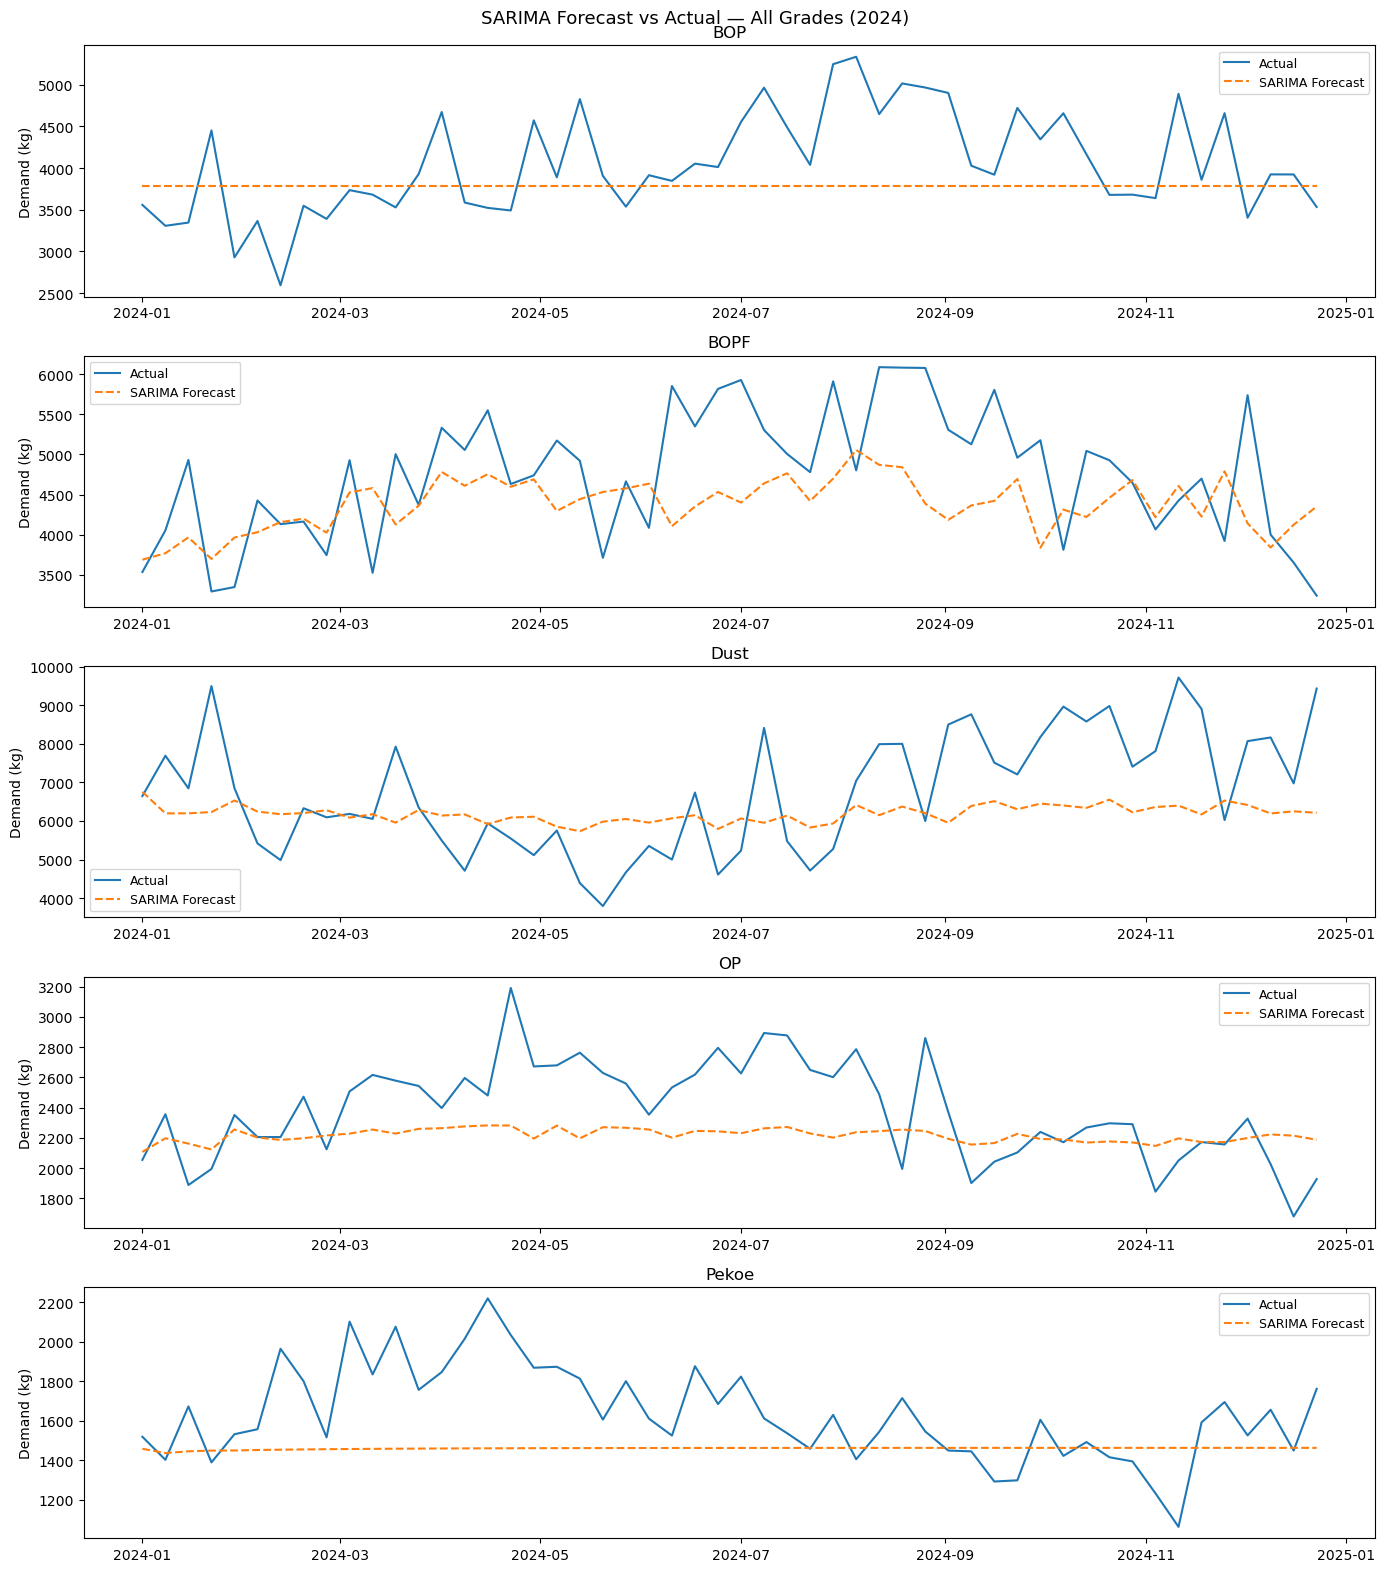

Saved → plots/sarima_forecast_all_grades.png


In [6]:
fig, axes = plt.subplots(len(grades_raw), 1, figsize=(14, 16), sharex=False)

for ax, grade in zip(axes, grades_raw):
    _, test = temporal_split(df[df['grade'] == grade])
    ax.plot(test['week_start_date'].values, test['demand_kg'].values,
            label='Actual', linewidth=1.5)
    ax.plot(test['week_start_date'].values, sarima_preds[grade],
            label='SARIMA Forecast', linewidth=1.5, linestyle='--')
    ax.set_title(f'{grade}')
    ax.set_ylabel('Demand (kg)')
    ax.legend(fontsize=9)

plt.suptitle('SARIMA Forecast vs Actual — All Grades (2024)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/sarima_forecast_all_grades.png', dpi=150)
plt.show()
print("Saved → plots/sarima_forecast_all_grades.png")